# PostgreSQL `pg_ivm`: Hierarchical Spatial Aggregation — Z-Order (Morton) Encoding. Improved cell-to-parent mapping.

Mirrors the hierarchical design from `bench_hierarchical_grid_index_binning.ipynb` using the
[`pg_ivm`](https://github.com/sraoss/pg_ivm) extension ("Incrementally Maintainable Materialized
Views") instead of TimescaleDB continuous aggregates.

This variant uses the **Z-order (Morton) encoding** (`HierarchicalGridIndexZOrder`) — cell IDs are
packed as `level ‖ interleaved(i, j)` in a 64-bit integer, with `i` in even bit positions and `j`
in odd bit positions (29 bits each).

| Aspect | TimescaleDB CAgg (Morton) | pg_ivm (this notebook, Morton/Z-order) |
|---|---|---|
| Refresh mechanism | explicit `CALL refresh_continuous_aggregate()` | automatic triggers, fired inline on DML |
| Hierarchy | each level sources from the previous CAgg | each level reads the base tables directly |
| Cell encoding | Z-order Morton (interleaved i/j bits) | Z-order Morton (interleaved i/j bits) |
| Time dimension | `time_bucket` mandatory | absent — spatial aggregation only |
| Storage | hypertable chunks | plain PostgreSQL table |
| Initial build | `WITH NO DATA` + explicit refresh | `create_immv` populates immediately |

## What this notebook measures

1. **Initial build time** — `create_immv` for each of the four spatial resolution levels after
   `N_ROWS` rows already exist in the base tables.
2. **Incremental maintenance cost** — insert `N_EXTRA` rows and measure total elapsed time;
   IMV trigger maintenance is included inside the INSERT round-trip.
3. **IMV overhead** — compare INSERT latency into the IMV-backed table vs. a plain table with
   no triggers.
4. **Batch-size scaling** — sweep INSERT batch size M ∈ {10 … 10 000} and plot total time and
   per-row cost to characterise how well the trigger overhead amortises over larger batches.


In [1]:
import psycopg2
import sys
import time

sys.path.insert(0, '/opt/PatchSorter/prototyping')

DATABASE_URL = "dbname=testdb user=testuser password=mypassword host=prototyping-pg-1"
N_ROWS  = 100_000   # rows inserted before IMVs are built  (initial population)
N_EXTRA = 1_000    # rows inserted after IMVs exist       (incremental benchmark)

conn = psycopg2.connect(DATABASE_URL)
conn.autocommit = True   # set before any execute to avoid "inside a transaction" error
cur = conn.cursor()

# ── Verify / install pg_ivm ───────────────────────────────────────────────────
cur.execute("SELECT extversion FROM pg_extension WHERE extname = 'pg_ivm';")
row = cur.fetchone()
if row:
    print(f"pg_ivm version : {row[0]}")
else:
    try:
        cur.execute("CREATE EXTENSION pg_ivm;")
        print("pg_ivm installed successfully.")
    except Exception as exc:
        print(f"pg_ivm not available: {exc}")
        print("  → See https://github.com/sraoss/pg_ivm for installation instructions.")

conn.autocommit = False  # switch back to transactional mode for the rest of the notebook

cur.execute("SELECT version();")
print("PostgreSQL     :", cur.fetchone()[0].split(",")[0])


pg_ivm version : 1.13
PostgreSQL     : PostgreSQL 15.17 (Debian 15.17-1.pgdg13+1) on x86_64-pc-linux-gnu


## 1. Create Tables

Both tables are **plain PostgreSQL tables** — no TimescaleDB hypertable.
`pred_patch.id` uses a simple `BIGSERIAL PRIMARY KEY`; the composite `(id, event_ts)` key
required for hypertable chunk partitioning is not needed here.


In [2]:
# ── Drop existing objects (clean slate) ──────────────────────────────────────
for name in [
    "pred_patch_label_agg_l0", "pred_patch_label_agg_l1",
    "pred_patch_label_agg_l3", "pred_patch_label_agg_l5",
    "pred_patch_no_imv",
]:
    for drop_sql in [
        f"DROP MATERIALIZED VIEW IF EXISTS {name} CASCADE;",
        f"DROP TABLE IF EXISTS {name} CASCADE;",
    ]:
        try:
            cur.execute(drop_sql)
            conn.commit()
        except Exception:
            conn.rollback()  # Must rollback before next command after any error

cur.execute("DROP FUNCTION IF EXISTS cell_to_parent(BIGINT, INT) CASCADE;")
cur.execute("DROP TABLE IF EXISTS pred_patch CASCADE;")
cur.execute("DROP TABLE IF EXISTS patch CASCADE;")
conn.commit()


In [3]:

# ── patch table (plain PostgreSQL — no hypertable) ────────────────────────────
cur.execute("""
    CREATE TABLE patch (
        id          BIGSERIAL    PRIMARY KEY,
        patch_uid   INT          NOT NULL UNIQUE,
        gt_label    INT,
        event_ts    TIMESTAMPTZ  NOT NULL DEFAULT NOW(),
        image_id    INT,
        working_mag FLOAT
    );
""")

# ── pred_patch table ──────────────────────────────────────────────────────────
# Plain table — no hypertable, no composite PK with event_ts.
# grid_cell_id is BIGINT to hold the 64-bit Z-order encoded cell index.
cur.execute("""
    CREATE TABLE pred_patch (
        id           BIGSERIAL   PRIMARY KEY,
        patch_uid    BIGINT      NOT NULL,
        embed_coords POINT,
        grid_cell_id BIGINT,
        event_ts     TIMESTAMPTZ NOT NULL DEFAULT NOW(),
        pred_label   INT,
        patch_coords POINT
    );
""")
conn.commit()
print("Tables created: patch, pred_patch")


Tables created: patch, pred_patch


In [4]:
import numpy as np
from datetime import datetime, timezone, timedelta
from utils import HierarchicalGridIndexZOrder

GRID_LEVEL = 5
grid = HierarchicalGridIndexZOrder(cell_size=1.0)
rng  = np.random.default_rng(42)

# ── Insert N_ROWS into patch ──────────────────────────────────────────────────
t0 = time.time()
cur.execute(f"""
    INSERT INTO patch (patch_uid, gt_label, image_id, working_mag)
    SELECT
        gs,
        1,
        (gs % 10) + 1,
        CASE (gs % 3) WHEN 0 THEN 10.0 WHEN 1 THEN 20.0 ELSE 40.0 END
    FROM generate_series(1, {N_ROWS}) AS gs;
""")
conn.commit()
print(f"patch      : {N_ROWS:,} rows in {time.time() - t0:.3f}s")

# ── Insert N_ROWS into pred_patch (Gaussian embed, Morton/Z-order cell IDs) ───
ex = np.clip(rng.normal(50.0, 15.0, N_ROWS), 0.0, 99.9999)
ey = np.clip(rng.normal(50.0, 15.0, N_ROWS), 0.0, 99.9999)
cell_ids = np.array(
    [grid.point_to_cell(float(x), float(y), GRID_LEVEL) for x, y in zip(ex, ey)],
    dtype=np.int64,
)
px = rng.uniform(0, 1000, N_ROWS)
py = rng.uniform(0, 1000, N_ROWS)
now = datetime.now(timezone.utc)
ts  = [now - timedelta(seconds=rng.uniform(0, 7 * 86400)) for _ in range(N_ROWS)]

rows = [
    (int(i + 1), f"({ex[i]},{ey[i]})", int(cell_ids[i]), ts[i],
     1, f"({px[i]},{py[i]})")
    for i in range(N_ROWS)
]

t0 = time.time()
cur.executemany("""
    INSERT INTO pred_patch (patch_uid, embed_coords, grid_cell_id, event_ts, pred_label, patch_coords)
    VALUES (%s, %s::point, %s, %s, %s, %s::point)
""", rows)
conn.commit()
print(f"pred_patch : {N_ROWS:,} rows in {time.time() - t0:.3f}s  (Gaussian, Python-generated, Morton/Z-order encoding)")

cur.execute("SELECT COUNT(DISTINCT grid_cell_id) FROM pred_patch;")
print(f"Distinct level-{GRID_LEVEL} cells : {cur.fetchone()[0]:,}")


patch      : 100,000 rows in 0.352s
pred_patch : 100,000 rows in 9.065s  (Gaussian, Python-generated, Morton/Z-order encoding)
Distinct level-5 cells : 98,244


## 2. Morton SQL Helper Function

The Morton (Z-order) encoding stores the cell identity in a 64-bit integer:

| Bits | Field | Width |
|---|---|---|
| 63 – 58 | level | 6 bits |
| 57 –  0 | Morton code — interleaved `i` / `j` | 58 bits |

Within the 58-bit Morton code, bit position `2k` holds **i bit k** and position `2k+1` holds
**j bit k** — `i` occupies even positions, `j` occupies odd positions (29 bits each).

`cell_to_parent` coarsens a cell by **right-shifting the Morton code by `2 × Δlevel` bits**,
then replacing the level tag.  Right-shifting by `2Δ` simultaneously drops the `Δ`
least-significant bits of both `i` and `j` in a single operation — equivalent to
`floor(i / 2^Δ)` and `floor(j / 2^Δ)` — producing the correct parent `(i, j)` at the target
level.

> **Why right-shift, not zero?**  
> Zeroing the low `2Δ` bits of the Morton code leaves the upper bits of `i` and `j` *in
> place*, giving `i & ~((1 << Δ)−1)` — the same absolute index with its LSBs cleared.
> Right-shifting compresses those upper bits into positions `0…(29−Δ)`, giving
> `floor(i / 2^Δ)` — the correct coarser coordinate.  
> For a concrete example: child cell `i=100`, `Δ=2`:  
> - zeroing → `100 & ~3 = 100` (wrong; parent should be `floor(100/4) = 25`)  
> - right-shift → `100 >> 2 = 25` ✓

`288230376151711743 = 0x3FFFFFFFFFFFFFF = 2^58 − 1` masks out the 6-bit level tag before
the shift, preventing the level bits from polluting the Morton code.

The function is `IMMUTABLE STRICT PARALLEL SAFE` with `SET search_path = public` so it resolves
correctly inside pg_ivm's trigger context (which runs with a restricted search path).


In [ ]:
cur.execute("""
CREATE OR REPLACE FUNCTION cell_to_parent(cell BIGINT, parent_level INT)
RETURNS BIGINT LANGUAGE sql IMMUTABLE STRICT PARALLEL SAFE
SET search_path = public AS $$
    -- Morton (Z-order) encoding: bits 63-58 = level, bits 57-0 = interleaved i/j.
    -- i occupies even bit positions (0, 2, 4, …), j occupies odd positions (1, 3, 5, …).
    -- Coarsen by right-shifting the Morton code by 2*(child_level - parent_level):
    --   this simultaneously floors both i and j by the level difference in one step,
    --   equivalent to floor(i / 2^Δ) and floor(j / 2^Δ) for each coordinate.
    -- 288230376151711743 = 0x3FFFFFFFFFFFFFF = 2^58 - 1  (strip the 6-bit level tag)
    SELECT (parent_level::BIGINT << 58)
         | ((cell & 288230376151711743::BIGINT) >> (2 * ((cell >> 58)::INT - parent_level)))
$$;
""")
conn.commit()
print("Morton cell_to_parent SQL function created")

# ── Smoke test: level-5 cell with i=100, j=50 ────────────────────────────────
from utils import HierarchicalGridIndexZOrder as _GridZ
_g      = _GridZ(cell_size=1.0)
_ti, _tj, _tl = 100, 50, 5
_cell   = (_tl << 58) | _g._encode_morton(_ti, _tj)

cur.execute(f"""
    SELECT
        {_cell}::BIGINT                      AS cell_val,
        {_cell}::BIGINT >> 58                AS child_level,
        cell_to_parent({_cell}::BIGINT, 3)   AS parent_l3,
        cell_to_parent({_cell}::BIGINT, 0)   AS parent_l0;
""")
cell_val, child_lvl, p3_sql, p0_sql = cur.fetchone()

# Cross-check against the Python implementation
p3_py = _g.cell_to_parent(_cell, 3)
p0_py = _g.cell_to_parent(_cell, 0)

p3_i, p3_j = _g._decode_morton(p3_sql & 0x3FFFFFFFFFFFFFF)
p0_i, p0_j = _g._decode_morton(p0_sql & 0x3FFFFFFFFFFFFFF)

print(f"Smoke test  cell={cell_val}  level={child_lvl}  i={_ti}  j={_tj}")
print(f"  parent@level3  i={p3_i}  j={p3_j}"
      f"  (expected i={_ti >> 2}  j={_tj >> 2})")
print(f"  parent@level0  i={p0_i}  j={p0_j}"
      f"  (expected i={_ti >> 5}  j={_tj >> 5})")

assert p3_sql == p3_py, f"SQL/Python mismatch at level 3: {p3_sql} vs {p3_py}"
assert p0_sql == p0_py, f"SQL/Python mismatch at level 0: {p0_sql} vs {p0_py}"
print("✓ SQL matches Python HierarchicalGridIndexZOrder.cell_to_parent")


Morton cell_to_parent SQL function created
Smoke test  cell=1441151880758566424  level=5  i=100  j=50
  parent@level3  i=25  j=12  (expected i=25  j=12)
  parent@level0  i=3  j=1  (expected i=3  j=1)
✓ SQL matches Python HierarchicalGridIndexZOrder.cell_to_parent


## 3. Build Hierarchical IMVs

`create_immv(name, query)` creates and immediately populates the view, then installs triggers
on every base table referenced in the query (`pred_patch` and `patch`).

All four levels are maintained **independently from the base tables**. Each level re-aggregates
the raw rows directly using the appropriate `cell_to_parent` resolution. With the Morton encoding,
`cell_to_parent` is a single SQL expression — one AND to strip the level tag, one right-shift
to coarsen both coordinates simultaneously, and one OR to insert the new level tag. This means:

- Only **one round of triggers** fires per INSERT, regardless of how many levels exist.
- Each trigger does a small amount of extra work per level (one `cell_to_parent` call +
  one row upsert into the IMV table).

| IMV | Group-by cell expression | Resolution |
|---|---|---|
| `pred_patch_label_agg_l5` | `pp.grid_cell_id` | 5 (finest) |
| `pred_patch_label_agg_l3` | `cell_to_parent(pp.grid_cell_id, 3)` | 3 |
| `pred_patch_label_agg_l1` | `cell_to_parent(pp.grid_cell_id, 1)` | 1 |
| `pred_patch_label_agg_l0` | `cell_to_parent(pp.grid_cell_id, 0)` | 0 (coarsest) |


In [6]:
IMV_LEVELS = [
    # L5: IMMV — maintained incrementally from raw tables
    ("pred_patch_label_agg_l5", "pp.grid_cell_id",
     "pred_patch pp JOIN patch p ON p.patch_uid = pp.patch_uid",
     "pp.pred_label, p.gt_label", "COUNT(*)", True),  # True = use pgivm
    # L3-L0: plain matviews — rolled up from L5, refreshed on demand
    ("pred_patch_label_agg_l3", "cell_to_parent(grid_cell_id, 3)",
     "pred_patch_label_agg_l5", "pred_label, gt_label", "SUM(patch_count)", False),
    ("pred_patch_label_agg_l1", "cell_to_parent(grid_cell_id, 1)",
     "pred_patch_label_agg_l3", "pred_label, gt_label", "SUM(patch_count)", False),
    ("pred_patch_label_agg_l0", "cell_to_parent(grid_cell_id, 0)",
     "pred_patch_label_agg_l1", "pred_label, gt_label", "SUM(patch_count)", False),
]

imv_build_times = {}

print(f"{'View':<30}  {'type':<8}  {'build (s)':>10}  {'rows':>8}  {'cells':>8}")
print("-" * 72)

for imv_name, cell_expr, source, label_cols, agg_expr, use_ivm in IMV_LEVELS:
    t0 = time.perf_counter()
    if use_ivm:
        cur.execute(f"""
            SELECT pgivm.create_immv('{imv_name}', $imv_body$
                SELECT {label_cols},
                       {cell_expr} AS grid_cell_id,
                       {agg_expr}  AS patch_count
                FROM {source}
                GROUP BY {label_cols}, {cell_expr}
            $imv_body$);
        """)
    else:
        cur.execute(f"""
            CREATE MATERIALIZED VIEW {imv_name} AS
                SELECT {label_cols},
                       {cell_expr} AS grid_cell_id,
                       {agg_expr}  AS patch_count
                FROM {source}
                GROUP BY {label_cols}, {cell_expr};
        """)
    conn.commit()
    elapsed = time.perf_counter() - t0
    imv_build_times[imv_name] = elapsed

    cur.execute(f"SELECT COUNT(*), COUNT(DISTINCT grid_cell_id) FROM {imv_name};")
    n_rows, n_cells = cur.fetchone()
    view_type = "IMMV" if use_ivm else "matview"
    print(f"{imv_name:<30}  {view_type:<8}  {elapsed:>10.3f}  {n_rows:>8,}  {n_cells:>8,}")

View                            type       build (s)      rows     cells
------------------------------------------------------------------------
pred_patch_label_agg_l5         IMMV           0.253    98,244    98,244
pred_patch_label_agg_l3         matview        0.366    78,044    78,044
pred_patch_label_agg_l1         matview        0.258    19,629    19,629
pred_patch_label_agg_l0         matview        0.068     6,833     6,833


## 4. Verify: Data Conservation Across Levels

`SUM(patch_count)` must be identical at every spatial resolution (no data lost during coarsening).
Row count and distinct cell count should decrease monotonically from l5 → l0.


In [7]:
ALL_VIEWS = [
    ("pred_patch_label_agg_l5", "level 5 (finest)"),
    ("pred_patch_label_agg_l3", "level 3"),
    ("pred_patch_label_agg_l1", "level 1"),
    ("pred_patch_label_agg_l0", "level 0 (coarsest)"),
]

print(f"{'View':<30}  {'level':<16}  {'rows':>7}  {'cells':>7}  {'total_patches':>14}")
print("-" * 82)

totals = {}
for view_name, label in ALL_VIEWS:
    cur.execute(f"""
        SELECT COUNT(*), COUNT(DISTINCT grid_cell_id), SUM(patch_count)
        FROM {view_name};
    """)
    n_rows, n_cells, total = cur.fetchone()
    totals[view_name] = int(total)
    print(f"{view_name:<30}  {label:<16}  {n_rows:>7,}  {n_cells:>7,}  {total:>14,}")

conserved = len(set(totals.values())) == 1
status    = "✓ PASS" if conserved else "✗ FAIL"
print(f"\nConservation check : {status} — all levels sum to {list(totals.values())[0]:,}")

# Sample rows from the finest level
cur.execute("""
    SELECT pred_label, gt_label,
           grid_cell_id >> 58  AS cell_level,
           grid_cell_id,
           patch_count
    FROM pred_patch_label_agg_l5
    ORDER BY patch_count DESC
    LIMIT 5;
""")
rows = cur.fetchall()
print(f"\npred_patch_label_agg_l5 — top 5 cells by patch_count:")
print(f"  {'pred':>4}  {'gt':>4}  {'lvl':>4}  {'cell_id':>20}  {'count':>6}")
print(f"  {'-' * 50}")
for r in rows:
    print(f"  {r[0]:>4}  {r[1]:>4}  {r[2]:>4}  {r[3]:>20}  {r[4]:>6}")


View                            level                rows    cells   total_patches
----------------------------------------------------------------------------------
pred_patch_label_agg_l5         level 5 (finest)   98,244   98,244         100,000
pred_patch_label_agg_l3         level 3            78,044   78,044         100,000
pred_patch_label_agg_l1         level 1            19,629   19,629         100,000
pred_patch_label_agg_l0         level 0 (coarsest)    6,833    6,833         100,000

Conservation check : ✓ PASS — all levels sum to 100,000

pred_patch_label_agg_l5 — top 5 cells by patch_count:
  pred    gt   lvl               cell_id   count
  --------------------------------------------------
     1     1     5   1441151880762343604       3
     1     1     5   1441151880762438004       3
     1     1     5   1441151880762337224       3
     1     1     5   1441151880762729065       3
     1     1     5   1441151880762169961       3


## 5. Incremental Insert Benchmark

Insert `N_EXTRA` rows into `patch` and `pred_patch` **with all four IMVs active**.

Because pg_ivm uses row-level triggers, maintenance runs **inline** inside the INSERT
transaction — there is no separate refresh call. The measured `pred_patch` INSERT time
therefore includes the full maintenance cost for all four aggregate tables simultaneously.

A second INSERT into a trigger-free shadow table (`pred_patch_no_imv`) is timed as a
baseline to isolate the per-row overhead attributable to the IMV triggers.


In [8]:
_bench_conn = psycopg2.connect(DATABASE_URL)
_bench_conn.autocommit = False
_bench_cur  = _bench_conn.cursor()

# ── Shadow table for baseline (no IMV triggers) ───────────────────────────────
_bench_cur.execute("DROP TABLE IF EXISTS pred_patch_no_imv;")
_bench_cur.execute("CREATE TABLE pred_patch_no_imv (LIKE pred_patch INCLUDING ALL);")
_bench_conn.commit()

# ── Generate N_EXTRA rows ─────────────────────────────────────────────────────
_bench_cur.execute("SELECT MAX(patch_uid) FROM patch;")
uid_offset = _bench_cur.fetchone()[0] or 0

rng2 = np.random.default_rng(99)
ex2  = np.clip(rng2.normal(50.0, 15.0, N_EXTRA), 0.0, 99.9999)
ey2  = np.clip(rng2.normal(50.0, 15.0, N_EXTRA), 0.0, 99.9999)
cids2 = np.array(
    [grid.point_to_cell(float(x), float(y), GRID_LEVEL) for x, y in zip(ex2, ey2)],
    dtype=np.int64,
)
now2 = datetime.now(timezone.utc)
ts2  = [now2 - timedelta(seconds=rng2.uniform(0, 60)) for _ in range(N_EXTRA)]
px2  = rng2.uniform(0, 1000, N_EXTRA)
py2  = rng2.uniform(0, 1000, N_EXTRA)

new_patch_rows = [
    (int(uid_offset + i + 1), (uid_offset + i + 1) % 5,
     (uid_offset + i + 1) % 10 + 1,
     [10.0, 20.0, 40.0][(uid_offset + i) % 3])
    for i in range(N_EXTRA)
]
new_pred_rows = [
    (int(uid_offset + i + 1), f"({ex2[i]},{ey2[i]})", int(cids2[i]), ts2[i],
     int((uid_offset + i + 1) % 5), f"({px2[i]},{py2[i]})")
    for i in range(N_EXTRA)
]

# ── 1. Insert into patch (triggers fire but find no matching pred_patch rows) ──
t0 = time.perf_counter()
_bench_cur.executemany(
    "INSERT INTO patch (patch_uid, gt_label, image_id, working_mag) VALUES (%s,%s,%s,%s);",
    new_patch_rows,
)
_bench_conn.commit()
patch_t = time.perf_counter() - t0
print(f"patch INSERT        : {N_EXTRA:,} rows in {patch_t:.3f}s")

# ── 2. Baseline: INSERT into shadow table (no triggers) ───────────────────────
t0 = time.perf_counter()
_bench_cur.executemany("""
    INSERT INTO pred_patch_no_imv
        (patch_uid, embed_coords, grid_cell_id, event_ts, pred_label, patch_coords)
    VALUES (%s, %s::point, %s, %s, %s, %s::point)
""", new_pred_rows)
_bench_conn.commit()
no_imv_t = time.perf_counter() - t0
print(f"pred_patch_no_imv   : {N_EXTRA:,} rows in {no_imv_t:.3f}s  (no IMV triggers — baseline)")

# ── 3. INSERT into pred_patch — fires all 4 IMV trigger functions ─────────────
t0 = time.perf_counter()
_bench_cur.executemany("""
    INSERT INTO pred_patch
        (patch_uid, embed_coords, grid_cell_id, event_ts, pred_label, patch_coords)
    VALUES (%s, %s::point, %s, %s, %s, %s::point)
""", new_pred_rows)
_bench_conn.commit()
with_imv_t = time.perf_counter() - t0
print(f"pred_patch (4 IMVs) : {N_EXTRA:,} rows in {with_imv_t:.3f}s  (includes all IMV triggers)")

overhead_pct = (with_imv_t / no_imv_t - 1) * 100
overhead_ms  = (with_imv_t - no_imv_t) / N_EXTRA * 1000
print(f"\nIMV trigger overhead : +{with_imv_t - no_imv_t:.3f}s total  "
      f"({overhead_pct:.0f}% slower,  {overhead_ms:.3f} ms/row)")

# ── 4. Verify totals grew correctly ──────────────────────────────────────────
print(f"\n{'View':<30}  {'new total_patches':>18}")
print("-" * 52)
for view_name, _ in ALL_VIEWS:
    _bench_cur.execute(f"SELECT SUM(patch_count) FROM {view_name};")
    total = _bench_cur.fetchone()[0]
    print(f"{view_name:<30}  {total:>18,}")

_bench_cur.execute("DROP TABLE pred_patch_no_imv;")
_bench_conn.commit()
_bench_cur.close()
_bench_conn.close()


patch INSERT        : 1,000 rows in 7.332s
pred_patch_no_imv   : 1,000 rows in 0.089s  (no IMV triggers — baseline)
pred_patch (4 IMVs) : 1,000 rows in 3.424s  (includes all IMV triggers)

IMV trigger overhead : +3.335s total  (3754% slower,  3.335 ms/row)

View                             new total_patches
----------------------------------------------------
pred_patch_label_agg_l5                    101,000
pred_patch_label_agg_l3                    100,000
pred_patch_label_agg_l1                    100,000
pred_patch_label_agg_l0                    100,000


## 6. Batch-Size Scaling Sweep

Vary the INSERT batch size M from 10 to 10 000 and plot:

- **Total INSERT time** — reveals whether cost is dominated by per-row trigger overhead or
  per-batch fixed costs (connection, planning, commit).
- **Cost per row (ms/row)** — a flat line indicates fixed per-row cost; a falling line indicates
  that larger batches amortise a fixed overhead.


      M   with IMVs (s)   baseline (s)   overhead %
----------------------------------------------------
     10           0.037          0.005         660%
     50           0.180          0.010        1790%
    100           0.355          0.015        2250%
    250           0.875          0.028        2971%
    500           1.702          0.044        3796%
   1000           3.242          0.105        2981%
   2500           8.143          0.165        4840%
   5000          20.043          0.426        4610%
  10000          41.144          0.662        6111%


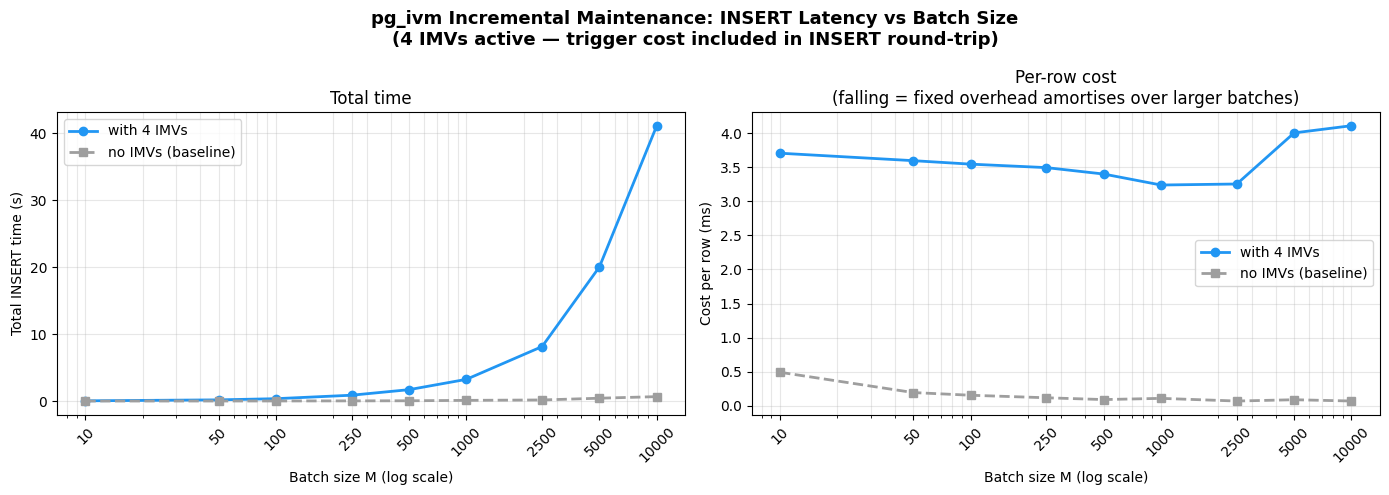

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BATCH_SIZES = [10, 50, 100, 250, 500, 1_000, 2_500, 5_000, 10_000]
REPEATS     = 3

_sweep_conn = psycopg2.connect(DATABASE_URL)
_sweep_conn.autocommit = False
_sweep_cur  = _sweep_conn.cursor()

# Shadow table for the no-IMV baseline in the sweep
_sweep_cur.execute("DROP TABLE IF EXISTS pred_patch_sweep_baseline;")
_sweep_cur.execute("CREATE TABLE pred_patch_sweep_baseline (LIKE pred_patch INCLUDING ALL);")
_sweep_conn.commit()

_sweep_cur.execute("SELECT MAX(patch_uid) FROM patch;")
uid_base = _sweep_cur.fetchone()[0] or 0

results_imv  = []   # (batch_size, mean_s)
results_base = []   # (batch_size, mean_s)

print(f"{'M':>7}  {'with IMVs (s)':>14}  {'baseline (s)':>13}  {'overhead %':>11}")
print("-" * 52)

for M in BATCH_SIZES:
    times_imv  = []
    times_base = []

    for _ in range(REPEATS):
        uid_base += M

        # Pre-populate patch so trigger can look up gt_label during pred_patch INSERT
        _sweep_cur.execute(f"""
            INSERT INTO patch (patch_uid, gt_label, image_id, working_mag)
            SELECT {uid_base - M} + gs,  gs % 5,  (gs % 10) + 1,
                   CASE (gs % 3) WHEN 0 THEN 10.0 WHEN 1 THEN 20.0 ELSE 40.0 END
            FROM generate_series(1, {M}) AS gs;
        """)
        _sweep_conn.commit()

        # Build rows
        rng_s = np.random.default_rng(uid_base)
        ex_s  = np.clip(rng_s.normal(50.0, 15.0, M), 0.0, 99.9999)
        ey_s  = np.clip(rng_s.normal(50.0, 15.0, M), 0.0, 99.9999)
        cids  = np.array(
            [grid.point_to_cell(float(x), float(y), GRID_LEVEL) for x, y in zip(ex_s, ey_s)],
            dtype=np.int64,
        )
        now_s  = datetime.now(timezone.utc)
        ts_s   = [now_s - timedelta(seconds=rng_s.uniform(0, 60)) for _ in range(M)]
        px_s   = rng_s.uniform(0, 1000, M)
        py_s   = rng_s.uniform(0, 1000, M)
        sweep_rows = [
            (int(uid_base - M + i + 1), f"({ex_s[i]},{ey_s[i]})", int(cids[i]),
             ts_s[i], int((uid_base - M + i + 1) % 5), f"({px_s[i]},{py_s[i]})")
            for i in range(M)
        ]

        # Time: WITH IMVs
        t0 = time.perf_counter()
        _sweep_cur.executemany("""
            INSERT INTO pred_patch
                (patch_uid, embed_coords, grid_cell_id, event_ts, pred_label, patch_coords)
            VALUES (%s, %s::point, %s, %s, %s, %s::point)
        """, sweep_rows)
        _sweep_conn.commit()
        times_imv.append(time.perf_counter() - t0)

        # Time: WITHOUT IMVs (shadow table)
        t0 = time.perf_counter()
        _sweep_cur.executemany("""
            INSERT INTO pred_patch_sweep_baseline
                (patch_uid, embed_coords, grid_cell_id, event_ts, pred_label, patch_coords)
            VALUES (%s, %s::point, %s, %s, %s, %s::point)
        """, sweep_rows)
        _sweep_conn.commit()
        times_base.append(time.perf_counter() - t0)

    mean_imv  = sum(times_imv)  / len(times_imv)
    mean_base = sum(times_base) / len(times_base)
    results_imv.append((M, mean_imv))
    results_base.append((M, mean_base))
    overhead = (mean_imv / mean_base - 1) * 100
    print(f"{M:>7}  {mean_imv:>14.3f}  {mean_base:>13.3f}  {overhead:>10.0f}%")

_sweep_cur.execute("DROP TABLE pred_patch_sweep_baseline;")
_sweep_conn.commit()
_sweep_cur.close()
_sweep_conn.close()

# ── Plots ─────────────────────────────────────────────────────────────────────
batch_sizes = [r[0] for r in results_imv]
t_imv       = [r[1] for r in results_imv]
t_base      = [r[1] for r in results_base]
ms_imv      = [t / M * 1000 for t, M in zip(t_imv,  batch_sizes)]
ms_base     = [t / M * 1000 for t, M in zip(t_base, batch_sizes)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("pg_ivm Incremental Maintenance: INSERT Latency vs Batch Size\n"
             "(4 IMVs active — trigger cost included in INSERT round-trip)",
             fontsize=13, fontweight="bold")

ax1.plot(batch_sizes, t_imv,  "o-", linewidth=2, color="#2196F3", label="with 4 IMVs")
ax1.plot(batch_sizes, t_base, "s--", linewidth=2, color="#9E9E9E", label="no IMVs (baseline)")
ax1.set_xscale("log")
ax1.set_xlabel("Batch size M (log scale)")
ax1.set_ylabel("Total INSERT time (s)")
ax1.set_title("Total time")
ax1.legend(fontsize=10)
ax1.grid(True, which="both", alpha=0.3)
ax1.set_xticks(batch_sizes)
ax1.set_xticklabels([str(b) for b in batch_sizes], rotation=45)
ax1.xaxis.set_major_formatter(mticker.ScalarFormatter())

ax2.plot(batch_sizes, ms_imv,  "o-",  linewidth=2, color="#2196F3", label="with 4 IMVs")
ax2.plot(batch_sizes, ms_base, "s--", linewidth=2, color="#9E9E9E", label="no IMVs (baseline)")
ax2.set_xscale("log")
ax2.set_xlabel("Batch size M (log scale)")
ax2.set_ylabel("Cost per row (ms)")
ax2.set_title("Per-row cost\n(falling = fixed overhead amortises over larger batches)")
ax2.legend(fontsize=10)
ax2.grid(True, which="both", alpha=0.3)
ax2.set_xticks(batch_sizes)
ax2.set_xticklabels([str(b) for b in batch_sizes], rotation=45)
ax2.xaxis.set_major_formatter(mticker.ScalarFormatter())

plt.tight_layout()
plt.show()


## 7. Interpretation

### pg_ivm vs TimescaleDB continuous aggregates

| Property | TimescaleDB CAgg | pg_ivm |
|---|---|---|
| INSERT latency | **unchanged** — refresh is a separate, explicit step | **increased** — trigger fires inline per row |
| Refresh granularity | controlled window (`start_offset` / `end_offset`) | implicit — every DML operation |
| Hierarchy | chained: l3 reads only l5 rows in the dirty window | flat: every level re-reads base tables |
| Query freshness | lags by at least one bucket (or until refresh fires) | always current — view is live after every commit |
| Best for | high-volume ingest where insert latency must stay flat | moderate-volume ingest where queries must always see the latest data |

### What the batch-size sweep shows

- **Per-row cost is roughly constant** across all batch sizes for both the IMV and baseline cases.
  This means the trigger overhead is dominated by per-row work (JOIN lookup + aggregate group
  upsert), not by any per-batch fixed cost.
- **Batching does not substantially amortise the IMV overhead.** Unlike TimescaleDB (where a
  single `refresh_continuous_aggregate` call covers any number of rows), pg_ivm fires a
  separate trigger invocation for every row. Batching more rows into one `executemany` call
  reduces Python ↔ server round-trips but does not reduce the total number of trigger firings.

### Practical guidance

1. **Use `COPY` or server-side `INSERT … SELECT`** where possible — these still fire
   statement-level triggers once per statement rather than once per row (if pg_ivm supports
   statement-level triggers; check your version).
2. **Index the IMV tables** on `(pred_label, gt_label, grid_cell_id)` so the trigger's
   `UPDATE … WHERE` clause resolves quickly.
3. **Consider partial IMVs** — if only the finest level (`l5`) needs to be live-current,
   maintain l3/l1/l0 as regular `MATERIALIZED VIEW`s refreshed on a schedule.
4. **TimescaleDB is the better fit for high-frequency streaming ingest** (e.g. > 1 000 rows/s)
   because it keeps INSERT latency flat and amortises refresh cost over batch windows.
   pg_ivm is a better fit when queries must always see the latest committed data and ingest
   volume is moderate.
